### Fine-tune model nhận dạng bàn tay

Notebook này fine-tune YOLOv8 cho bài toán hand detection trên dataset mới `hand_train_fine_tune`, giữ bố cục gần giống `train_m1.ipynb` để dễ theo dõi.

## 1. Import Thư Viện

In [11]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
from ultralytics import YOLO

from src.m1 import HandDetectionModel

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: 0


## 2. Load Dataset

In [12]:
# Define paths
DATA_ROOT = Path('data/processed_frames')
TRAIN_DIR = DATA_ROOT / 'hand_train_fine_tune'
VAL_DIR = DATA_ROOT / 'hand_test'
TRAIN_IMAGES = TRAIN_DIR / 'images'
TRAIN_LABELS = TRAIN_DIR / 'labels'
VAL_IMAGES = VAL_DIR / 'images'
VAL_LABELS = VAL_DIR / 'labels'
DATA_YAML = DATA_ROOT / 'hand_detection_fine_tune.yaml'

BATCH_SIZE = 16
NUM_WORKERS = 0
IMG_SIZE = 640
CONFIDENCE = 0.25

# Fine-tune from the best hand detection checkpoint if it exists
BASE_MODEL_PATH = Path('./models/best_model_m1.pt')
if not BASE_MODEL_PATH.exists():
    BASE_MODEL_PATH = Path('yolov8n.pt')

# Create YOLO data yaml if it does not exist
if not DATA_YAML.exists():
    yaml_text = f'''path: {DATA_ROOT.as_posix()}
train: hand_train_fine_tune/images
val: hand_test/images
nc: 1
names: ['hand']
'''
    DATA_YAML.write_text(yaml_text, encoding='utf-8')

def count_files(folder, extensions=('.jpg', '.jpeg', '.png', '.bmp')):
    if not folder.exists():
        return 0
    return sum(1 for file_path in folder.iterdir() if file_path.suffix.lower() in extensions)

classes_path = DATA_ROOT / 'classes.txt'
classes_text = classes_path.read_text(encoding='utf-8').strip() if classes_path.exists() else 'Unknown'

print('Loading dataset...')
print(f'Train images: {count_files(TRAIN_IMAGES)}')
print(f'Train labels: {count_files(TRAIN_LABELS, extensions=(".txt",))}')
print(f'Validation images: {count_files(VAL_IMAGES)}')
print(f'Validation labels: {count_files(VAL_LABELS, extensions=(".txt",))}')
print(f'Data yaml: {DATA_YAML}')
print(f'Classes: {classes_text}')
print(f'Base model: {BASE_MODEL_PATH}')

Loading dataset...
Train images: 154
Train labels: 154
Validation images: 510
Validation labels: 510
Data yaml: data\processed_frames\hand_detection_fine_tune.yaml
Classes: hand
Base model: models\best_model_m1.pt


## 3. Xây Dựng Model

In [13]:
# Initialize model
print('Initializing hand detection model for fine-tuning...')
detector = HandDetectionModel(str(BASE_MODEL_PATH))

print(f'Loaded base model: {BASE_MODEL_PATH}')
print('Task: hand detection fine-tuning')

Initializing hand detection model for fine-tuning...
Loaded base model: models\best_model_m1.pt
Task: hand detection fine-tuning


## 4. Cấu Hình Training

In [14]:
# Fine-tuning hyperparameters
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PROJECT_DIR = Path('./runs/hand_detection_fine_tune')
EXPERIMENT_NAME = 'train_m1_fine_tune'

# Training history placeholder
history = {
    'epoch': [],
    'train/box_loss': [],
    'train/cls_loss': [],
    'train/dfl_loss': [],
    'metrics/precision(B)': [],
    'metrics/recall(B)': [],
    'metrics/mAP50(B)': [],
    'metrics/mAP50-95(B)': []
}

print('Fine-tuning configuration:')
print(f'  Base model: {BASE_MODEL_PATH}')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Image size: {IMG_SIZE}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Weight decay: {WEIGHT_DECAY}')
print(f'  Device: {device}')
print(f'  Project dir: {PROJECT_DIR}')
print(f'  Experiment: {EXPERIMENT_NAME}')

Fine-tuning configuration:
  Base model: models\best_model_m1.pt
  Epochs: 25
  Batch size: 16
  Image size: 640
  Learning rate: 0.0001
  Weight decay: 0.0001
  Device: 0
  Project dir: runs\hand_detection_fine_tune
  Experiment: train_m1_fine_tune


## 5. Vòng Lặp Training

In [15]:
print('Starting fine-tuning...\n')
train_result = detector.train(
    data=str(DATA_YAML),
    epochs=NUM_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=NUM_WORKERS,
    device=device,
    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    patience=10,
    optimizer='AdamW',
    lr0=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    plots=True,
    save=True,
    pretrained=True,
    resume=False
)

trainer = getattr(detector.model, 'trainer', None)
if trainer is not None and getattr(trainer, 'save_dir', None) is not None:
    save_dir = Path(trainer.save_dir)
elif isinstance(train_result, dict) and 'save_dir' in train_result:
    save_dir = Path(train_result['save_dir'])
else:
    save_dir = PROJECT_DIR / EXPERIMENT_NAME

best_weights = save_dir / 'weights' / 'best.pt'
results_csv = save_dir / 'results.csv'

print('\n' + '=' * 50)
print('Training completed!')
print(f'Best weights: {best_weights}')
print(f'Results csv: {results_csv}')

Starting fine-tuning...

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.69  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\processed_frames\hand_detection_fine_tune.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

## 6. Đánh Giá Hiệu Xuất

In [16]:
# Validate the best model
print('Validating fine-tuned model...')
eval_model_path = str(best_weights if best_weights.exists() else BASE_MODEL_PATH)
eval_detector = HandDetectionModel(eval_model_path)
val_metrics = eval_detector.validate(
    data=str(DATA_YAML),
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=device
)

metrics_dict = getattr(val_metrics, 'results_dict', {}) if val_metrics is not None else {}
metrics_df = pd.DataFrame([metrics_dict]) if metrics_dict else pd.DataFrame()

print('\n' + '=' * 50)
print('EVALUATION METRICS')
print('=' * 50)
if not metrics_df.empty:
    print(metrics_df.to_string(index=False))
else:
    print('No validation metrics returned by the model.')

if hasattr(val_metrics, 'box') and hasattr(val_metrics.box, 'map50'):
    print(f'mAP50: {val_metrics.box.map50:.4f}')
if hasattr(val_metrics, 'box') and hasattr(val_metrics.box, 'map'):
    print(f'mAP50-95: {val_metrics.box.map:.4f}')

Validating fine-tuned model...
Ultralytics 8.4.69  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 741.6176.6 MB/s, size: 32.4 KB)
val: Scanning D:\vscode\Python\projects\sign-language-pipline\data\processed_frames\hand_test\labels.cache... 510 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 510/510  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 9.9it/s 3.2s<0.2s
                   all        510       1003      0.828      0.598       0.72      0.365
Speed: 1.5ms preprocess, 2.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to D:\vscode\Python\projects\sign-language-pipline\runs\detect\val-6

EVALUATION METRICS
 metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  fitness
              0.82753       

## 7. Biểu Đồ & Trực Quan Hóa

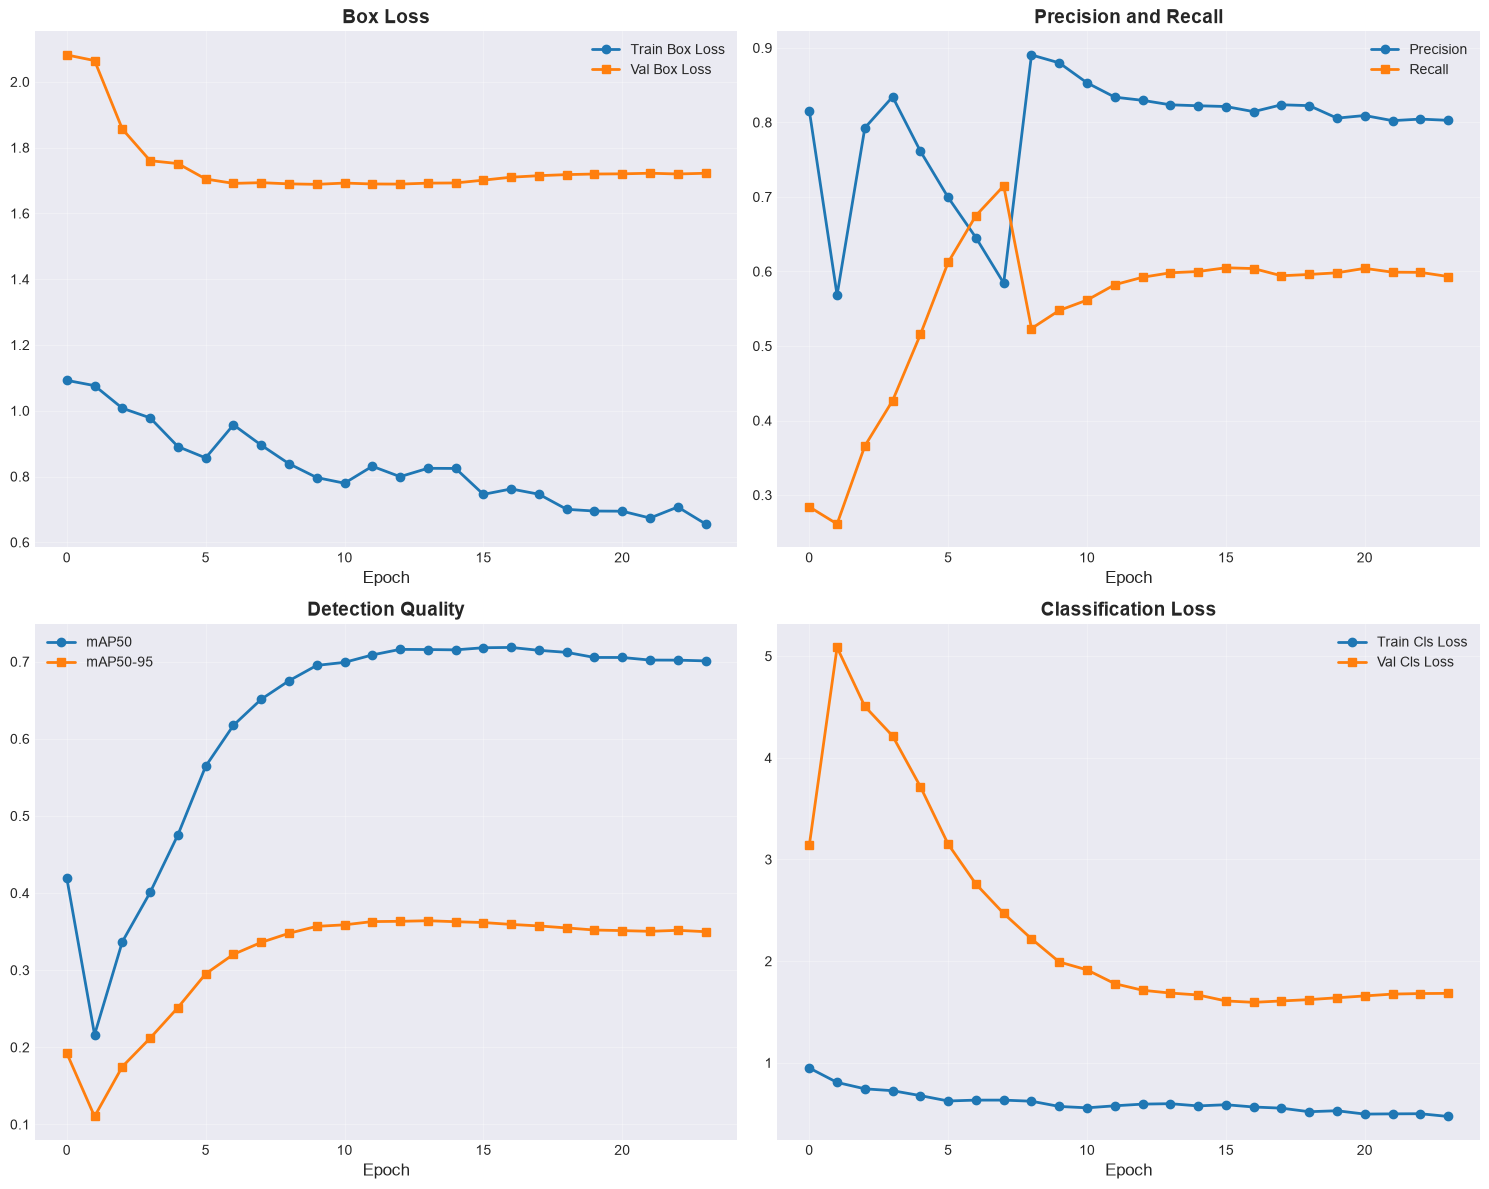


✓ Training results saved to ./outputs/training_results_m1_fine_tune.png


In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

if results_csv.exists():
    history_df = pd.read_csv(results_csv)
else:
    history_df = pd.DataFrame()

if not history_df.empty:
    if 'train/box_loss' in history_df.columns and 'val/box_loss' in history_df.columns:
        axes[0, 0].plot(history_df['train/box_loss'], label='Train Box Loss', marker='o', linewidth=2)
        axes[0, 0].plot(history_df['val/box_loss'], label='Val Box Loss', marker='s', linewidth=2)
        axes[0, 0].set_title('Box Loss', fontsize=14, fontweight='bold')
    if 'metrics/precision(B)' in history_df.columns and 'metrics/recall(B)' in history_df.columns:
        axes[0, 1].plot(history_df['metrics/precision(B)'], label='Precision', marker='o', linewidth=2)
        axes[0, 1].plot(history_df['metrics/recall(B)'], label='Recall', marker='s', linewidth=2)
        axes[0, 1].set_title('Precision and Recall', fontsize=14, fontweight='bold')
    if 'metrics/mAP50(B)' in history_df.columns and 'metrics/mAP50-95(B)' in history_df.columns:
        axes[1, 0].plot(history_df['metrics/mAP50(B)'], label='mAP50', marker='o', linewidth=2)
        axes[1, 0].plot(history_df['metrics/mAP50-95(B)'], label='mAP50-95', marker='s', linewidth=2)
        axes[1, 0].set_title('Detection Quality', fontsize=14, fontweight='bold')
    if 'train/cls_loss' in history_df.columns and 'val/cls_loss' in history_df.columns:
        axes[1, 1].plot(history_df['train/cls_loss'], label='Train Cls Loss', marker='o', linewidth=2)
        axes[1, 1].plot(history_df['val/cls_loss'], label='Val Cls Loss', marker='s', linewidth=2)
        axes[1, 1].set_title('Classification Loss', fontsize=14, fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'No classification loss in detection run', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_axis_off()
else:
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'No training history found', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

for ax in axes.flat:
    ax.set_xlabel('Epoch', fontsize=12)
    ax.grid(True, alpha=0.3)
    if ax.has_data():
        ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('./outputs/training_results_m1_fine_tune.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Training results saved to ./outputs/training_results_m1_fine_tune.png')

## 8. Lưu Mô Hình & Tóm Sắt

In [18]:
# Save training summary
summary = {
    'Model': 'YOLOv8n (Hand Detection Fine-tune)',
    'Dataset Root': str(DATA_ROOT),
    'Train Images': count_files(TRAIN_IMAGES),
    'Validation Images': count_files(VAL_IMAGES),
    'Batch Size': BATCH_SIZE,
    'Image Size': IMG_SIZE,
    'Learning Rate': LEARNING_RATE,
    'Weight Decay': WEIGHT_DECAY,
    'Num Epochs': NUM_EPOCHS,
    'Base Model': str(BASE_MODEL_PATH),
    'Best Weights': str(best_weights),
}

if not metrics_df.empty:
    for column in metrics_df.columns:
        summary[column] = metrics_df.iloc[0][column]

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print('\n' + '=' * 50)
print('TRAINING SUMMARY')
print('=' * 50)
print(summary_df.to_string(index=False))

summary_df.to_csv('./outputs/training_summary_m1_fine_tune.csv', index=False)
print("\n✓ Summary saved to './outputs/training_summary_m1_fine_tune.csv'")

if results_csv.exists():
    history_df.to_csv('./outputs/training_metrics_m1_fine_tune.csv', index=False)
    print("✓ Detailed metrics saved to './outputs/training_metrics_m1_fine_tune.csv'")

if best_weights.exists():
    model_output_path = Path('./models/best_model_m1_fine_tune.pt')
    model_output_path.parent.mkdir(parents=True, exist_ok=True)
    model_output_path.write_bytes(best_weights.read_bytes())
    print(f"✓ Best model weights saved to '{model_output_path}'")
else:
    print('Best weights were not found, so no model file was copied.')

print('\n' + '=' * 50)
print('FINE-TUNING COMPLETED SUCCESSFULLY!')
print('=' * 50)


TRAINING SUMMARY
              Metric                                                                                                                          Value
               Model                                                                                             YOLOv8n (Hand Detection Fine-tune)
        Dataset Root                                                                                                          data\processed_frames
        Train Images                                                                                                                            154
   Validation Images                                                                                                                            510
          Batch Size                                                                                                                             16
          Image Size                                                                          

## 9. Test

Running inference on: data\processed_frames\hand_test\images\VOC2007_101.jpg

image 1/1 d:\vscode\Python\projects\sign-language-pipline\data\processed_frames\hand_test\images\VOC2007_101.jpg: 480x640 1 hand, 3.7ms
Speed: 1.1ms preprocess, 3.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


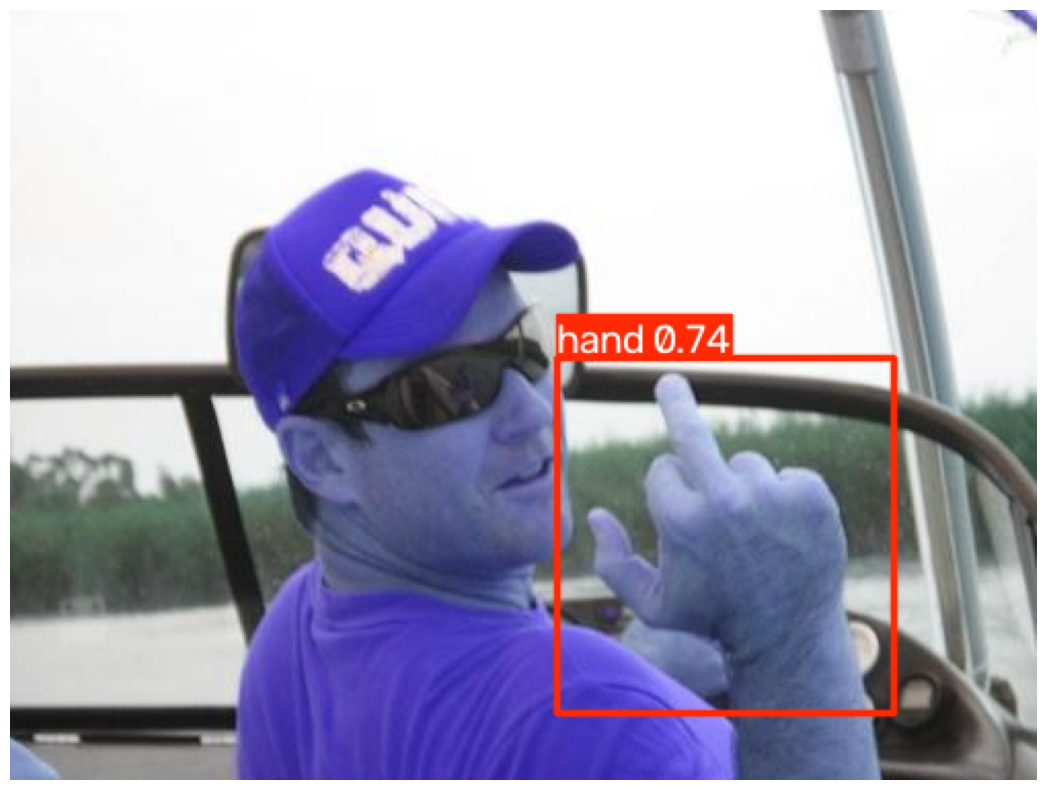


✓ Sample predictions saved to './outputs/sample_predictions_m1_fine_tune.png'


In [19]:
# Load best model for inference
test_model_path = str(best_weights if best_weights.exists() else BASE_MODEL_PATH)
test_detector = HandDetectionModel(test_model_path)

sample_image = next(iter(VAL_IMAGES.glob('*.jpg')), None)
if sample_image is None:
    sample_image = next(iter(VAL_IMAGES.glob('*.png')), None)

if sample_image is None:
    print('No sample image found in validation folder.')
else:
    print(f'Running inference on: {sample_image}')
    prediction = test_detector.predict(str(sample_image), imgsz=IMG_SIZE, conf=CONFIDENCE, device=device)[0]
    annotated_image = prediction.plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('./outputs/sample_predictions_m1_fine_tune.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Sample predictions saved to './outputs/sample_predictions_m1_fine_tune.png'")